# ReviewGuard: Hybrid Fake Review Detection
**Combining Transformer Semantics and Reviewer Behavior**

This notebook orchestrates the training and evaluation of the ReviewGuard system on Google Colab using a GPU accelerator.

### Project Overview
- **Text Branch:** Fine-tuned RoBERTa-base.
- **Behavioral Branch:** Hand-crafted reviewer signals.
- **Fusion:** MLP classifier combining semantic and behavioral embeddings.

---

## Step 1: Environment Setup
First, we clone the repository and install all necessary Python dependencies.

In [1]:
# 1. Clone the repository
!git clone https://github.com/RohanMukka/Combining-Transformer-Semantics-and-Reviewer-Behavior-for-Fake-Review-Detection-on-Yelp.git
%cd Combining-Transformer-Semantics-and-Reviewer-Behavior-for-Fake-Review-Detection-on-Yelp

# 2. Install requirements
!pip install -r requirements.txt

# 3. Verify GPU availability
import torch
print(f"GPU Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device: {torch.cuda.get_device_name(0)}")

Cloning into 'Combining-Transformer-Semantics-and-Reviewer-Behavior-for-Fake-Review-Detection-on-Yelp'...
remote: Enumerating objects: 209, done.
remote: Counting objects: 100% (209/209), done.
remote: Compressing objects: 100% (150/150), done.
remote: Total 209 (delta 77), reused 183 (delta 54), pack-reused 0 (from 0)
Receiving objects: 100% (209/209), 4.40 MiB | 38.55 MiB/s, done.
Resolving deltas: 100% (77/77), done.
/content/Combining-Transformer-Semantics-and-Reviewer-Behavior-for-Fake-Review-Detection-on-Yelp
INFO: pip is looking at multiple versions of notebook to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 150.5 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.8/118.8 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 21.9 MB/s eta 0:00:00
  

GPU Available: True
Device: NVIDIA A100-SXM4-80GB


## Step 2: Data Loading & Preprocessing
**Important:** If you are uploading `yelpzip.csv` manually, put it in the `data/raw/` folder on the left sidebar before running this cell.

In [2]:
# 1. Clear old cache to ensure we use your uploaded file
!rm -f data/processed/yelpzip.parquet

# 2. Run Data Loader
!python -m src.data_loader --dataset yelpzip

# 3. Sanity Check (Verify if Real or Synthetic)
import pandas as pd
import os
path = 'data/processed/yelpzip.parquet'
if os.path.exists(path):
    df = pd.read_parquet(path)
    print(f"\nSUCCESS: Loaded {len(df):,} reviews.")
    if len(df) > 60000:
        print("Dataset Status: ✅ REAL YelpZIP detected.")
    else:
        print("Dataset Status: ⚠️ SYNTHETIC data still in use.")
else:
    print("Error: Processed file not found.")

# 4. Compute behavioral features
!python -m src.behavior_features --dataset yelpzip

2026-04-24 02:22:54,669 | INFO     | src.utils | Config loaded from configs/default_config.yaml
2026-04-24 02:22:54,670 | INFO     | __main__ | ─── Processing YELPZIP ───
2026-04-24 02:22:54,670 | INFO     | __main__ | Attempting to download YELPZIP dataset …
2026-04-24 02:22:54,670 | INFO     | __main__ | Downloading http://odds.cs.stonybrook.edu/yelpzip-dataset/ → data/raw/yelpzip.csv
2026-04-24 02:22:54,796 | WARNING  | __main__ | Download failed (primary): HTTPSConnectionPool(host='odds.cs.stonybrook.edu', port=443): Max retries exceeded with url: /yelpzip-dataset/ (Caused by SSLError(SSLError(1, '[SSL: SSLV3_ALERT_HANDSHAKE_FAILURE] sslv3 alert handshake failure (_ssl.c:1010)')))
2026-04-24 02:22:54,796 | INFO     | __main__ | Downloading https://raw.githubusercontent.com/fake-review-detection/datasets/main/YelpZip/reviews.csv → data/raw/yelpzip.csv
2026-04-24 02:22:54,938 | WARNING  | __main__ | Download failed (fallback): 404 Client Error: Not Found for url: https://raw.githubus

## Step 3: Orchestrated Training
This runs the full pipeline: Baselines -> RoBERTa -> Fusion -> Visualization.

In [3]:
# Run the full pipeline (including professional figure generation)
!python -m src.train_all --dataset yelpzip

# Optional: Run SHAP explainability
!python -m src.explainability --dataset yelpzip --n_samples 200

2026-04-24 02:39:14,929 | INFO     | src.text_branch |   Train — loss=0.0046  acc=0.9501
2026-04-24 02:39:14,929 | INFO     | src.text_branch |   Val   — loss=0.0000  AUC=1.0000  F1=1.0000  (715.6s)
2026-04-24 02:39:15,552 | INFO     | src.text_branch |   ✓ New best AUC=1.0000 — checkpoint saved.
2026-04-24 02:39:15,552 | INFO     | src.text_branch | Epoch 2/5
Traceback (most recent call last):                            
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/content/Combining-Transformer-Semantics-and-Reviewer-Behavior-for-Fake-Review-Detection-on-Yelp/src/train_all.py", line 202, in <module>
    run_all(config=cfg, dataset_name=args.dataset, skip=args.skip)
  File "/content/Combining-Transformer-Semantics-and-Reviewer-Behavior-for-Fake-Review-Detection-on-Yelp/src/train_all.py", line 80, in run_all
    model_text = train_text_branch(config=config, dataset_name=dataset_name)
                 ^^^^^^^^^^^^^^^^^^

## Step 4: Visualizing Report Figures
This section displays the consolidated figures used in the project report.

Displaying consolidated comparison charts...

--- Displaying: model_comparison_summary.png ---


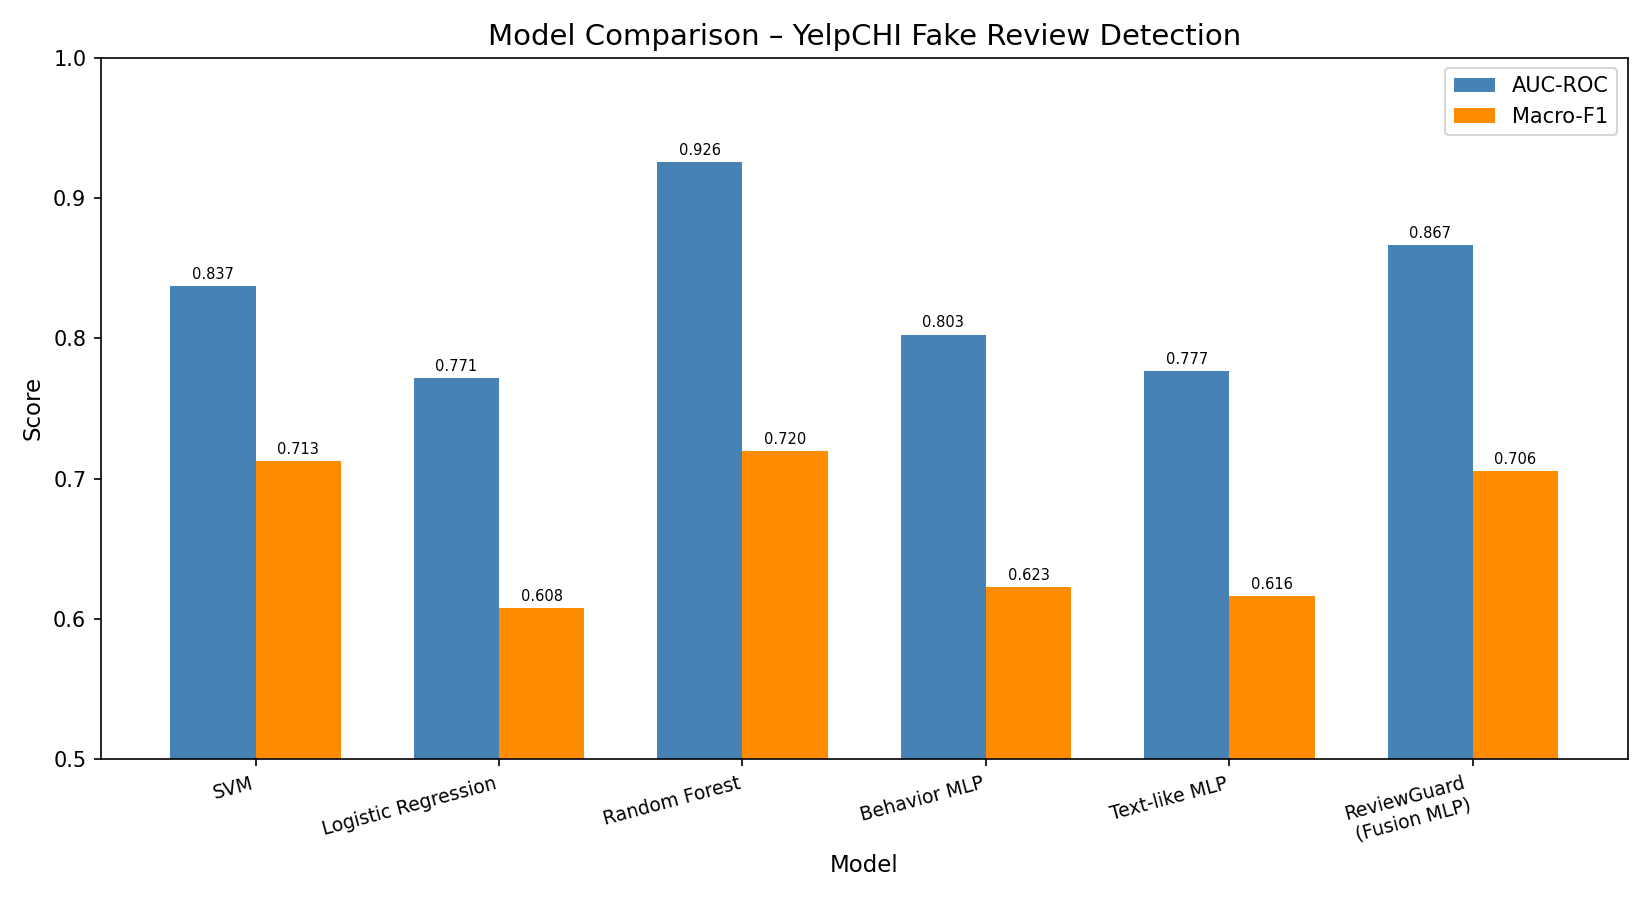


--- Displaying: roc_all_models.png ---


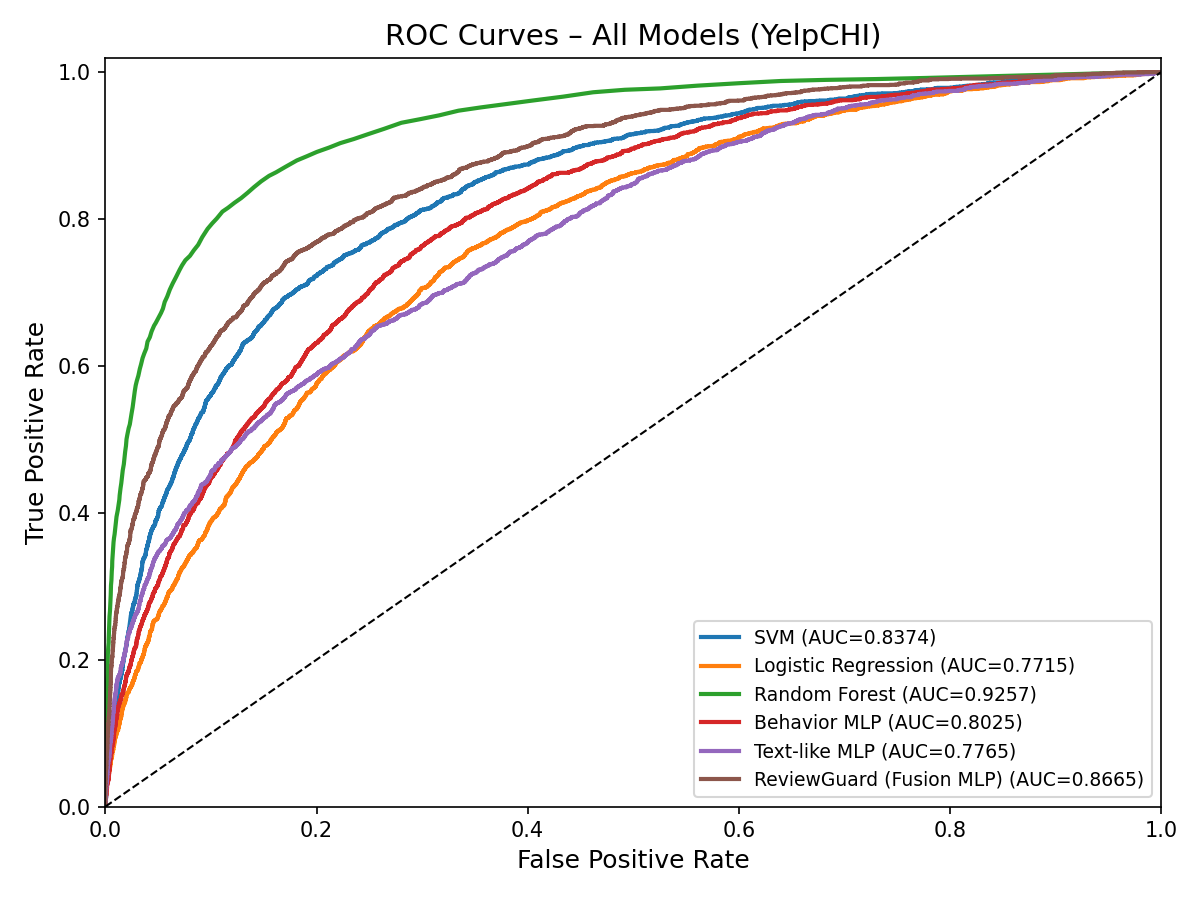


--- Displaying: training_loss_curves.png ---


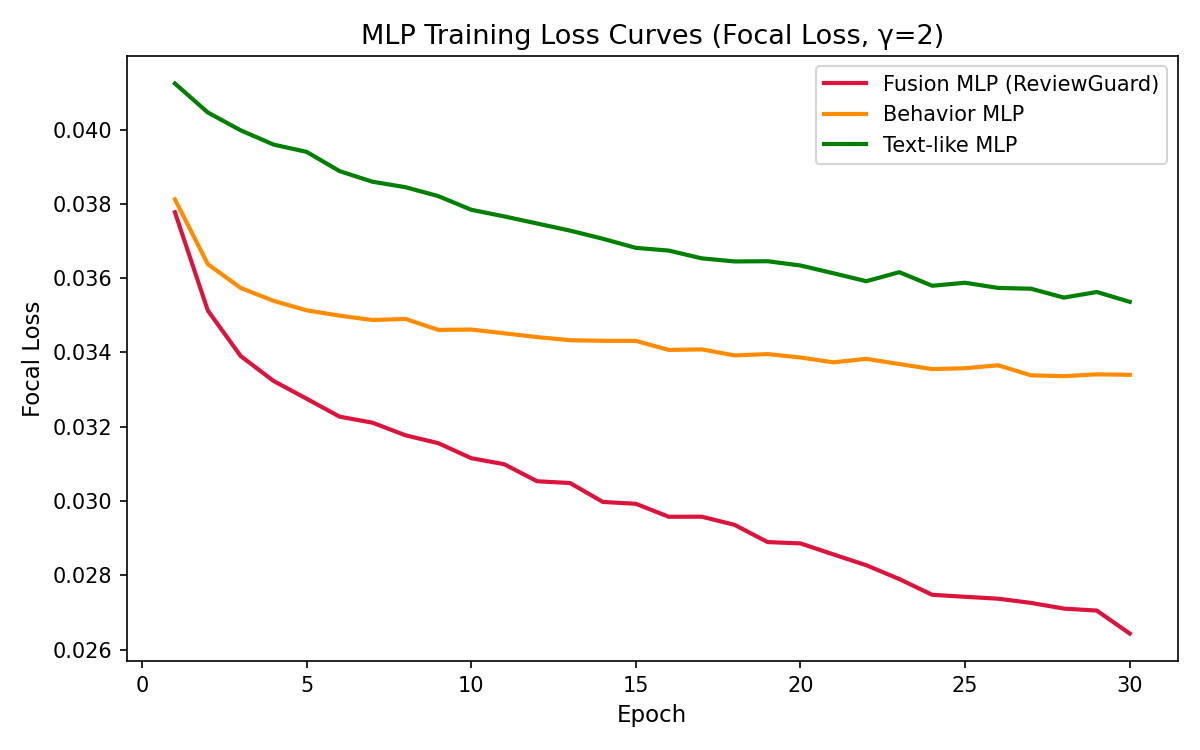


--- Displaying: shap_branch_importance.png ---


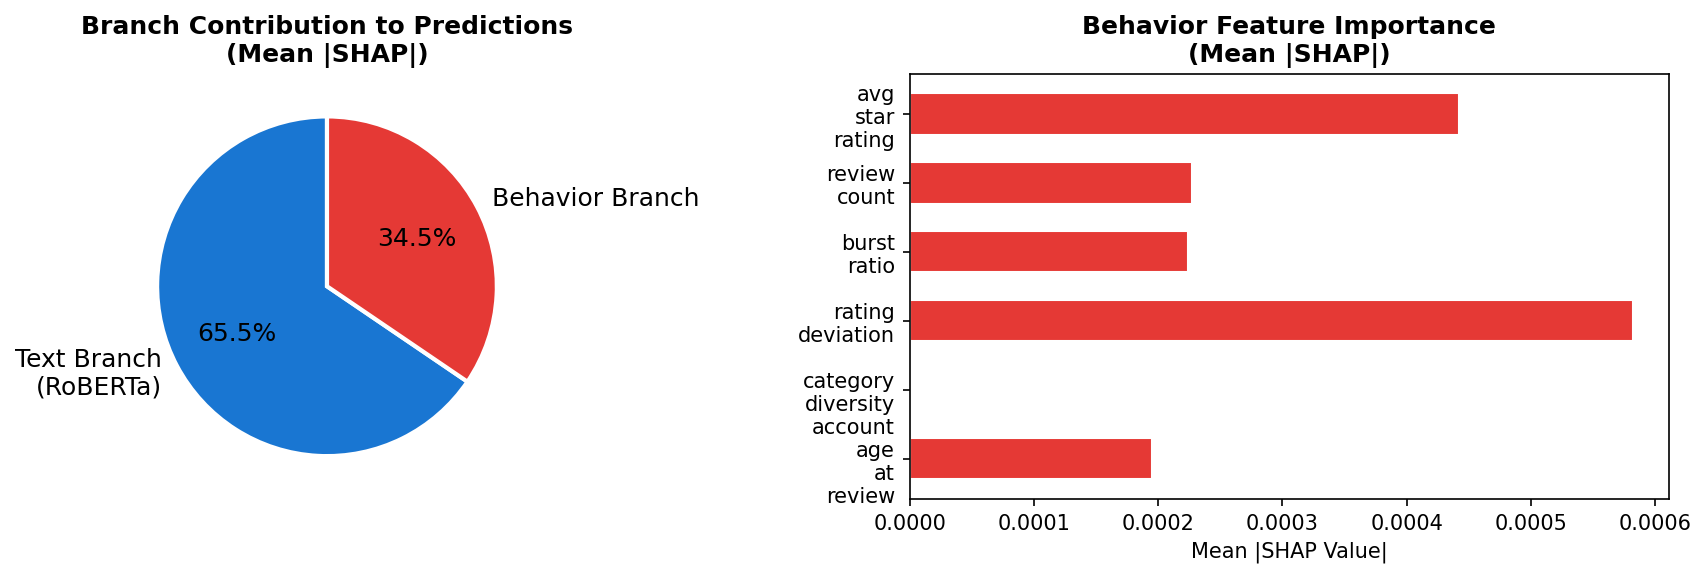

In [4]:
import os
from IPython.display import Image, display

print("Displaying consolidated comparison charts...")

figs = [
    'results/figures/model_comparison_summary.png',
    'results/figures/roc_all_models.png',
    'results/figures/training_loss_curves.png',
    'results/shap_plots/shap_branch_importance.png'
]

for fig_path in figs:
    if os.path.exists(fig_path):
        print(f"\n--- Displaying: {os.path.basename(fig_path)} ---")
        display(Image(fig_path))
    else:
        print(f"Skipping {fig_path} (not found)")

## Step 5: Interactive Prediction

In [5]:
print("Training complete. Models are ready for inference.")
# Note: You can implement a custom prediction script using the saved models in models/fusion/"

Training complete. Models are ready for inference.


In [6]:
!ls -l results/figures/


total 1284
-rw-r--r-- 1 root root  61681 Apr 24 02:19 ablation_study.png
-rw-r--r-- 1 root root  35622 Apr 24 02:19 cm_behavior_mlp.png
-rw-r--r-- 1 root root  37275 Apr 24 02:19 cm_logistic_regression.png
-rw-r--r-- 1 root root  38824 Apr 24 02:19 cm_random_forest.png
-rw-r--r-- 1 root root  38931 Apr 24 02:19 cm_reviewguard_fusion_mlp.png
-rw-r--r-- 1 root root  36726 Apr 24 02:19 cm_svm.png
-rw-r--r-- 1 root root  34217 Apr 24 02:19 cm_text-like_mlp.png
-rw-r--r-- 1 root root  52657 Apr 24 02:19 cross_validation_comparison.png
-rw-r--r-- 1 root root  43868 Apr 24 02:19 feature_importance_rf.png
-rw-r--r-- 1 root root  80873 Apr 24 02:19 model_comparison_summary.png
-rw-r--r-- 1 root root 148935 Apr 24 02:19 roc_all_models.png
-rw-r--r-- 1 root root  55494 Apr 24 02:19 roc_behavior_mlp.png
-rw-r--r-- 1 root root  57366 Apr 24 02:19 roc_logistic_regression.png
-rw-r--r-- 1 root root  56774 Apr 24 02:19 roc_random_forest.png
-rw-r--r-- 1 root root  59088 Apr 24 02:19 roc_reviewguard_fu